<a href="https://colab.research.google.com/github/esraozdemir6/DogHealthPredictor/blob/main/MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("dog_breed_health_data.csv")

dataset_name = "Canine Wellness Dataset"
dataset_link = "https://www.kaggle.com/datasets/aaronisomaisom3/canine-wellness-dataset-synthetic-10k-samples"

# record ve feature sayısı
num_records = df.shape[0]
num_features = df.shape[1] - 1  #ıd sütunu 0

# target
target_column = 'Healthy'
num_classes = df[target_column].nunique()
examples_per_class = df[target_column].value_counts().to_dict()

# Eksik değerlerin sütun bazında sayısı
missing_values = df.isnull().sum().to_dict()

# Sayısal olmayan sütunlar
non_numeric_features = df.select_dtypes(include='object').columns.tolist()

print("• Dataset Name:", dataset_name)
print("• Dataset Web Link:", dataset_link)
print("• Number of Records:", num_records)
print("• Number of Features (excluding ID):", num_features)
print("• Number of Target Classes:", num_classes)
print("• Number of Examples per Class:", examples_per_class)
print("• Number of Missing (NULL) Values per Feature:")
for feature, count in missing_values.items():
    print(f"   - {feature}: {count}")
print("• Non-Numeric Features:", non_numeric_features)


• Dataset Name: Canine Wellness Dataset
• Dataset Web Link: https://www.kaggle.com/datasets/aaronisomaisom3/canine-wellness-dataset-synthetic-10k-samples
• Number of Records: 10000
• Number of Features (excluding ID): 20
• Number of Target Classes: 2
• Number of Examples per Class: {'Yes': 7178, 'No': 2500}
• Number of Missing (NULL) Values per Feature:
   - ID: 0
   - Breed: 290
   - Breed Size: 288
   - Sex: 325
   - Age: 291
   - Weight (lbs): 291
   - Spay/Neuter Status: 3567
   - Daily Activity Level: 2230
   - Diet: 302
   - Food Brand: 300
   - Daily Walk Distance (miles): 294
   - Other Pets in Household: 298
   - Medications: 249
   - Seizures: 301
   - Hours of Sleep: 279
   - Play Time (hrs): 309
   - Owner Activity Level: 2227
   - Annual Vet Visits: 306
   - Average Temperature (F): 345
   - Synthetic: 310
   - Healthy: 322
• Non-Numeric Features: ['Breed', 'Breed Size', 'Sex', 'Spay/Neuter Status', 'Daily Activity Level', 'Diet', 'Food Brand', 'Other Pets in Household', '

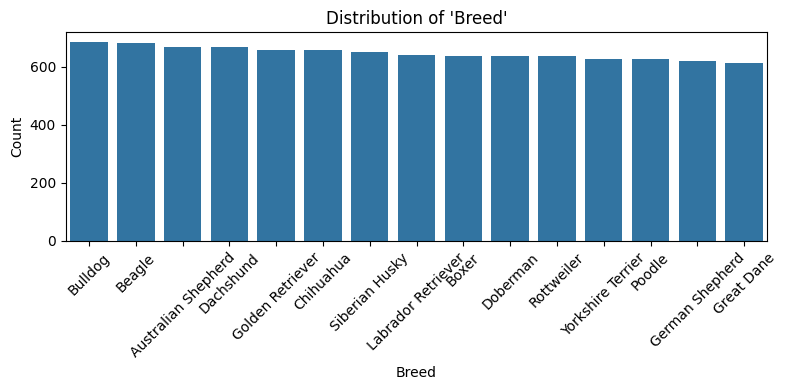

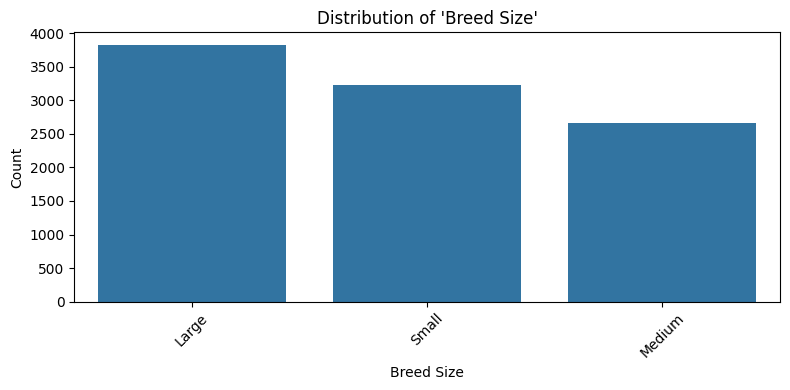

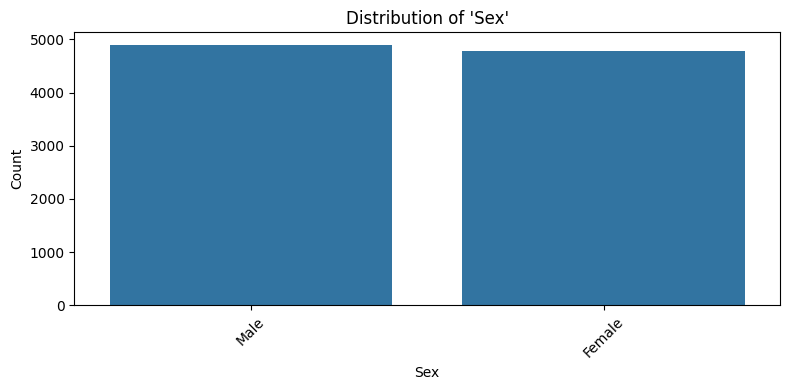

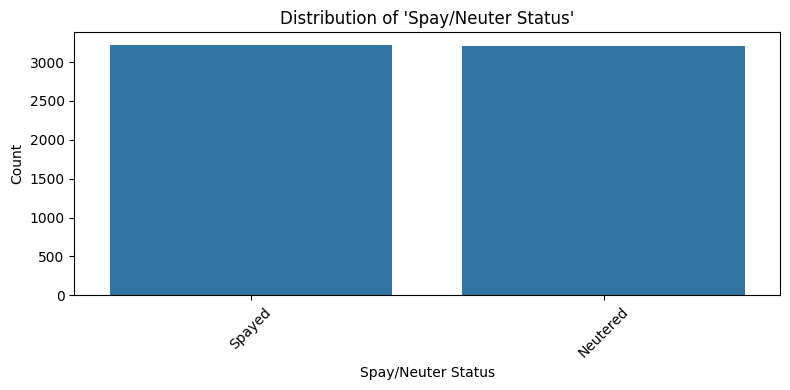

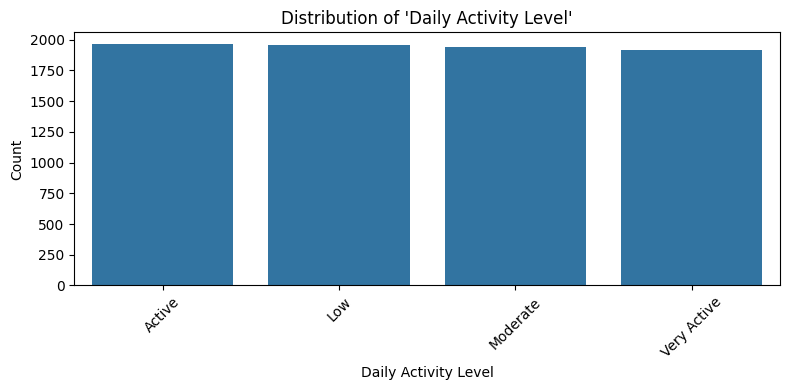

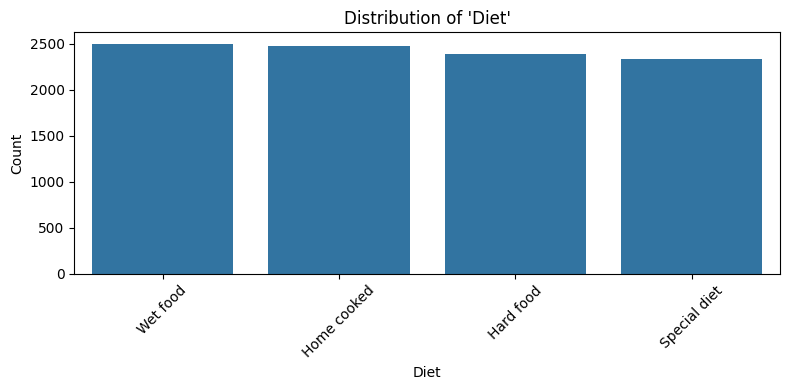

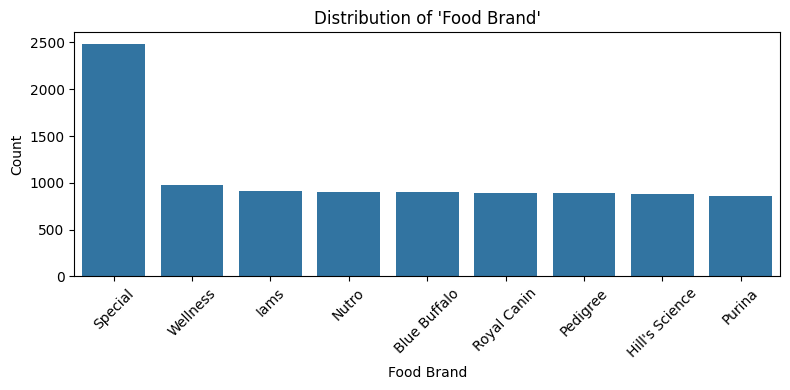

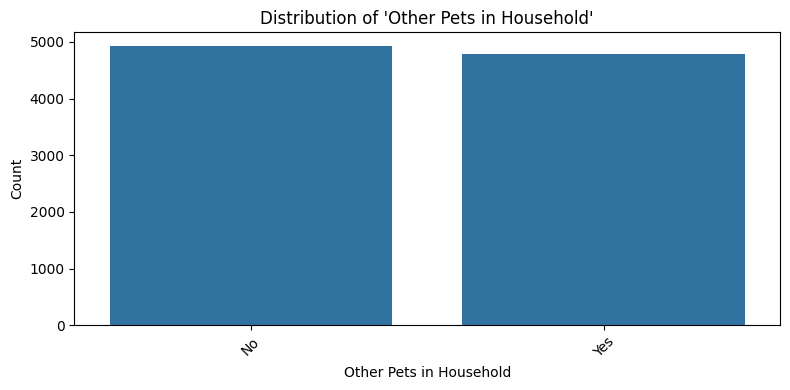

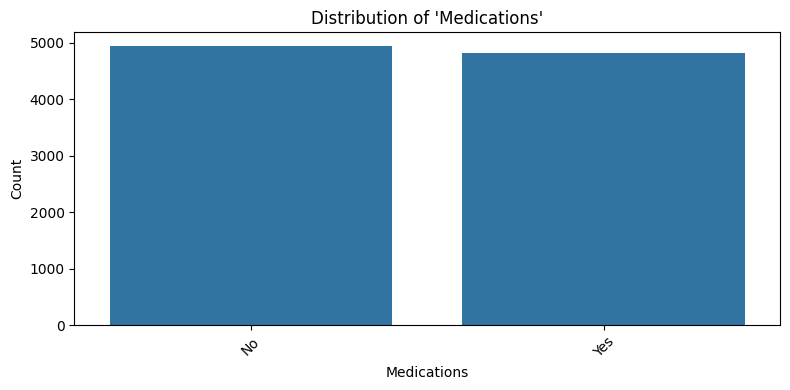

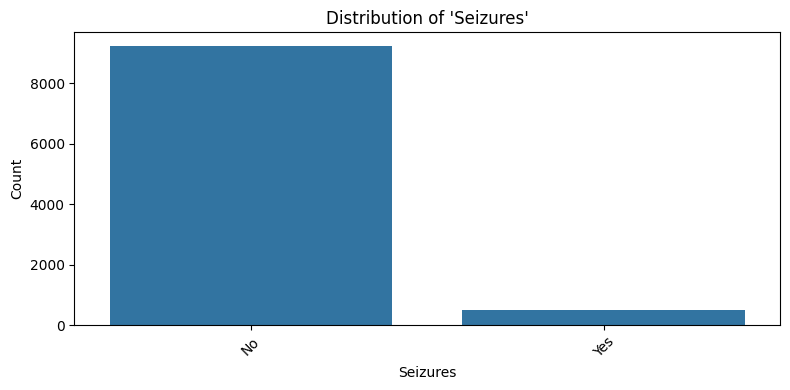

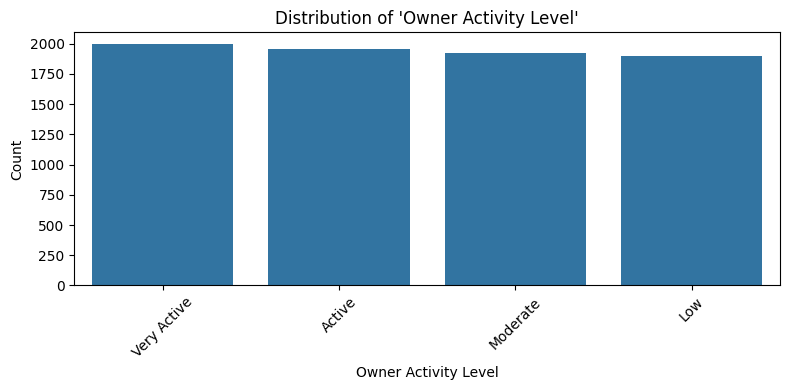

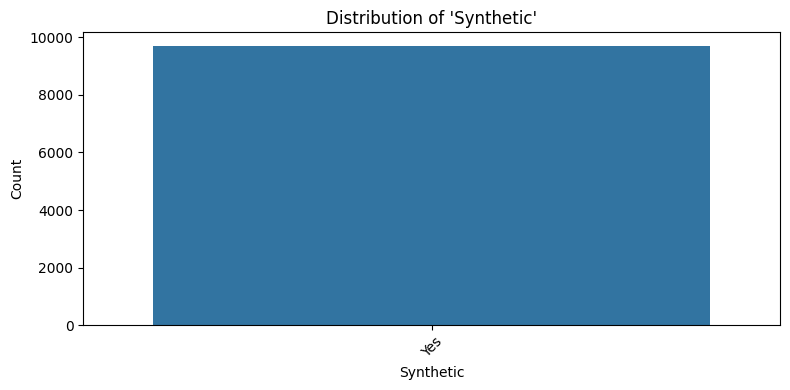

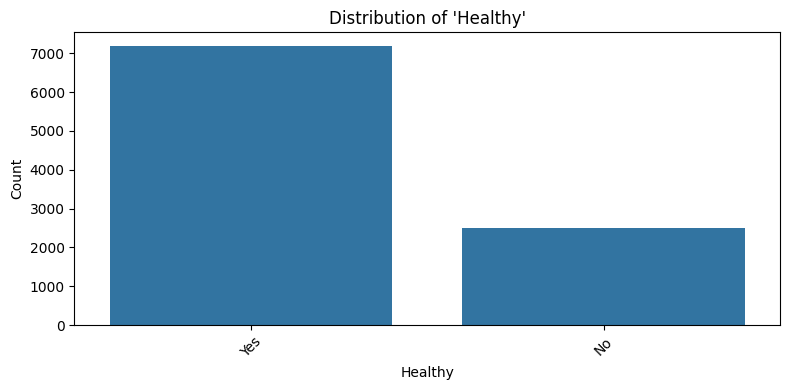

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kategorik sütunları belirle
categorical_cols = df.select_dtypes(include='object').columns

# Kategorik sütunlar için dağılım grafiği
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of '{col}'")
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


In [ ]:
# Sadece sayısal sütunlar
numerical_cols = df.select_dtypes(include=['number'])

numerical_stats = pd.DataFrame({
    'Min': numerical_cols.min(),
    'Max': numerical_cols.max(),
    'Mean': numerical_cols.mean()
})

print("Numerical Feature Statistics (Min, Max, Mean):")
display(numerical_stats)


Numerical Feature Statistics (Min, Max, Mean):


,Min,Max,Mean
ID,1.0,10000.0,5000.500000
Age,1.0,13.0,7.063858
Weight (lbs),10.0,109.0,50.202493
Daily Walk Distance (miles),0.0,8.0,2.527818
Hours of Sleep,8.0,14.0,11.006995
Play Time (hrs),0.0,4.0,1.524095
Annual Vet Visits,0.0,4.0,1.474727
Average Temperature (F),30.0,100.0,64.559606


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include='object').columns

# LabelEncoder nesnesini sadece bir kez oluşturuyoruz
le = LabelEncoder()

# Her sütuna encoding uygula
for col in categorical_cols:
    #geiçici unknown
    df[col] = df[col].fillna("Unknown")

    # Label Encoding
    df[col] = le.fit_transform(df[col])

    print(f"✓ Label Encoding applied to '{col}' column.")


✓ Label Encoding applied to 'Breed' column.
✓ Label Encoding applied to 'Breed Size' column.
✓ Label Encoding applied to 'Sex' column.
✓ Label Encoding applied to 'Spay/Neuter Status' column.
✓ Label Encoding applied to 'Daily Activity Level' column.
✓ Label Encoding applied to 'Diet' column.
✓ Label Encoding applied to 'Food Brand' column.
✓ Label Encoding applied to 'Other Pets in Household' column.
✓ Label Encoding applied to 'Medications' column.
✓ Label Encoding applied to 'Seizures' column.
✓ Label Encoding applied to 'Owner Activity Level' column.
✓ Label Encoding applied to 'Synthetic' column.
✓ Label Encoding applied to 'Healthy' column.


In [ ]:
import pandas as pd

# geçici unknown
df["Food Brand"] = df["Food Brand"].fillna("Unknown")

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=["Food Brand"], prefix="FoodBrand")

print("One-Hot Encoding applied to 'Food Brand' column.")
print("New columns created:")
print([col for col in df_encoded.columns if col.startswith("FoodBrand_")])


One-Hot Encoding applied to 'Food Brand' column.
New columns created:
['FoodBrand_0', 'FoodBrand_1', 'FoodBrand_2', 'FoodBrand_3', 'FoodBrand_4', 'FoodBrand_5', 'FoodBrand_6', 'FoodBrand_7', 'FoodBrand_8', 'FoodBrand_9']


In [ ]:
# 1. %3ten fazla eksik veriye sahip sütunları sil
missing_ratio = df.isnull().mean()
columns_to_drop = missing_ratio[missing_ratio > 0.03].index.tolist()
df = df.drop(columns=columns_to_drop)

print("Dropped columns due to high missing ratio (>3%):")
print(columns_to_drop)

# 2. Healthy eksikse, satırı sil
before_rows = df.shape[0]
df = df.dropna(subset=["Healthy"])
after_rows = df.shape[0]

print(f"\nDeleted {before_rows - after_rows} rows with missing 'Healthy' target values.")

# 3. Sayısal sütunlardaki eksik verileri mean ile doldur
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())
        print(f"Filled missing values in '{col}' with mean: {df[col].mean():.2f}")

Dropped columns due to high missing ratio (>3%):
['Play Time (hrs)', 'Annual Vet Visits', 'Average Temperature (F)']

Deleted 0 rows with missing 'Healthy' target values.
Filled missing values in 'Age' with mean: 7.06
Filled missing values in 'Weight (lbs)' with mean: 50.20
Filled missing values in 'Daily Walk Distance (miles)' with mean: 2.53
Filled missing values in 'Hours of Sleep' with mean: 11.01


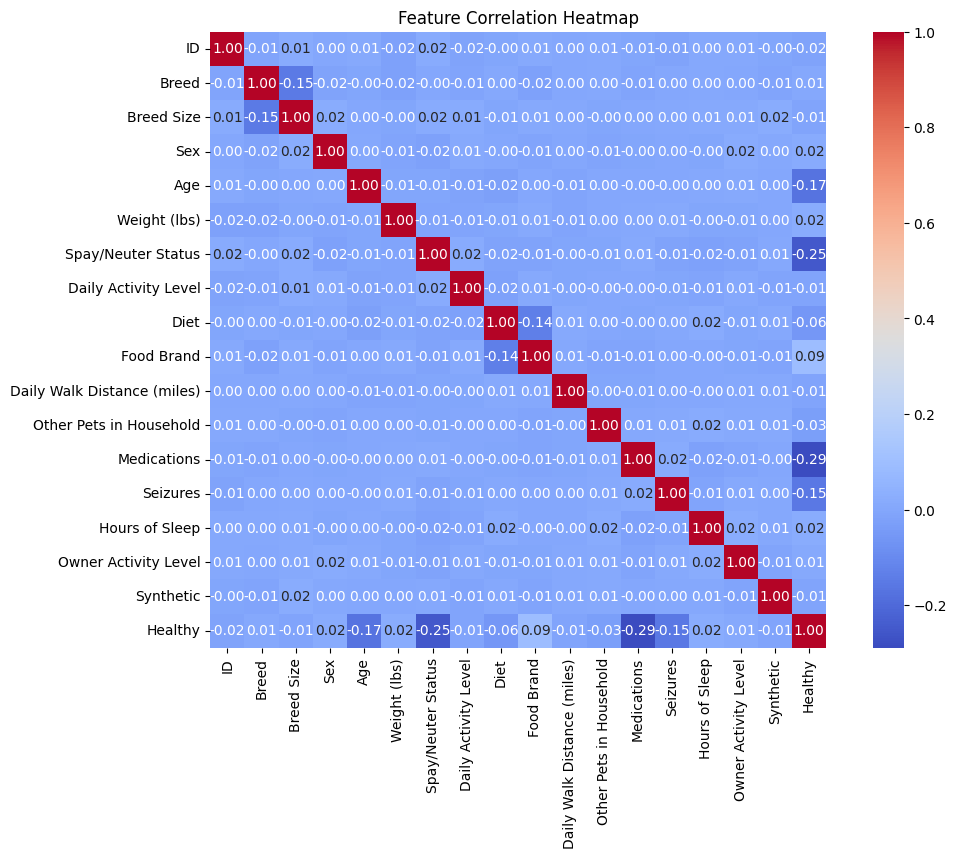


Highly Correlated Feature Pairs (correlation > 0.5):
Series([], dtype: float64)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sadece sayısal sütunlar
numeric_df = df.select_dtypes(include=['number'])

# Korelasyon matrisini hesaplama
correlation_matrix = numeric_df.corr()

# Korelasyon matrisini heatmap e çevirme
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

# En yüksek korelasyona sahip sütun çiftlerini listele (kendisiyle olanlar hariç)
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
high_corr_pairs = corr_pairs[(corr_pairs < 1.0) & (corr_pairs > 0.5)]

print("\nHighly Correlated Feature Pairs (correlation > 0.5):")
print(high_corr_pairs)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Sayısal sütunlar(ID ve hedef hariç)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
columns_to_scale = [col for col in numeric_cols if col not in ["ID"]]

# Normalizasyon öncesi ilk 5 satırı göster
print("Before Normalization:")
display(df[columns_to_scale].head())

# Normalizasyon
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df_scaled[columns_to_scale])

# Normalizasyon sonrası ilk 5 satırı göster
print("After Normalization:")
display(df_scaled[columns_to_scale].head())


Before Normalization:


,Breed,Breed Size,Sex,Age,Weight (lbs),Spay/Neuter Status,Daily Activity Level,Diet,Food Brand,Daily Walk Distance (miles),Other Pets in Household,Medications,Seizures,Hours of Sleep,Owner Activity Level,Synthetic,Healthy
0,0,1,1,3.0,60.0,0,3,3,9,5.0,0,2,0,12.0,0,1,2
1,5,3,0,4.0,57.0,0,4,1,7,2.0,2,0,0,11.0,3,1,1
2,4,2,0,12.0,67.0,0,0,1,7,1.0,2,0,0,10.0,1,1,2
3,13,1,1,13.0,35.0,2,4,3,7,4.0,0,0,0,12.0,3,1,2
4,2,1,1,13.0,35.0,2,4,4,5,3.0,2,2,0,9.0,3,1,0


After Normalization:


,Breed,Breed Size,Sex,Age,Weight (lbs),Spay/Neuter Status,Daily Activity Level,Diet,Food Brand,Daily Walk Distance (miles),Other Pets in Household,Medications,Seizures,Hours of Sleep,Owner Activity Level,Synthetic,Healthy
0,0.000000,0.333333,0.5,0.166667,0.505051,0.0,0.75,0.75,1.000000,0.625,0.0,1.0,0.0,0.666667,0.00,1.0,1.0
1,0.333333,1.000000,0.0,0.250000,0.474747,0.0,1.00,0.25,0.777778,0.250,1.0,0.0,0.0,0.500000,0.75,1.0,0.5
2,0.266667,0.666667,0.0,0.916667,0.575758,0.0,0.00,0.25,0.777778,0.125,1.0,0.0,0.0,0.333333,0.25,1.0,1.0
3,0.866667,0.333333,0.5,1.000000,0.252525,1.0,1.00,0.75,0.777778,0.500,0.0,0.0,0.0,0.666667,0.75,1.0,1.0
4,0.133333,0.333333,0.5,1.000000,0.252525,1.0,1.00,1.00,0.555556,0.375,1.0,1.0,0.0,0.166667,0.75,1.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score

# Healthyi kontrol et
df['Healthy'] = df['Healthy'].fillna("Unknown")
label_encoder = LabelEncoder()
df['Healthy_LE'] = label_encoder.fit_transform(df['Healthy'])  # Label Encoding

# Apply Min-Max
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[df.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(df[df.select_dtypes(include=["float64", "int64"]).columns])

X = df_scaled.drop(columns=["ID", "Healthy", "Healthy_LE"])
y = df['Healthy_LE']  # Healthy_LE target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check if splitting works
print("Train data shape:", X_train.shape)
print("Test data shape:", X_test.shape)


Train data shape: (8000, 16)
Test data shape: (2000, 16)


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

print(f"Logistic Regression Accuracy: {log_acc:.4f}")


Logistic Regression Accuracy: 0.7565


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

print(f"Decision Tree Accuracy: {tree_acc:.4f}")


Decision Tree Accuracy: 0.7845


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc:.4f}")


Random Forest Accuracy: 0.8580


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print(f"K-Nearest Neighbors Accuracy: {knn_acc:.4f}")


K-Nearest Neighbors Accuracy: 0.7650


In [ ]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"Support Vector Machine Accuracy: {svm_acc:.4f}")


Support Vector Machine Accuracy: 0.8140


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Target'ın sayısal halini kullan
df['Healthy'] = df['Healthy'].fillna("Unknown")
df['Healthy_LE'] = LabelEncoder().fit_transform(df['Healthy'])

# Feature ve targetı ayır
X = df.select_dtypes(include=['number']).drop(columns=['ID', 'Healthy_LE'])  # sayısal sütunlar
y = df['Healthy_LE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Deep Learning için veri tipini dönüştür
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)


In [ ]:
# DNN
dnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_np.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.fit(X_train_np, y_train_np, epochs=10, batch_size=32, verbose=1)

dnn_loss, dnn_acc = dnn_model.evaluate(X_test_np, y_test_np)
print(f"\nDNN Accuracy: {dnn_acc:.4f}")


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.0305 - loss: -122.2838
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0319 - loss: -4036.7847
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0302 - loss: -23333.4805
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0295 - loss: -71710.6406
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0302 - loss: -154717.3750
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0310 - loss: -275023.5000
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0300 - loss: -442238.9688
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0298 - loss: -672220.1875
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0319 - loss: -953426.3125
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0288 - loss: -1336775.0000
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0396 - loss: -1718846.8750

DNN Accuracy: 0

In [ ]:
# CNN için veriyi 3D'ye dönüştür
X_train_cnn = X_train_np[..., np.newaxis]
X_test_cnn = X_test_np[..., np.newaxis]

cnn_model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_cnn, y_train_np, epochs=10, batch_size=32, verbose=1)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_np)
print(f"\nCNN Accuracy: {cnn_acc:.4f}")


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0332 - loss: -307.3535
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0312 - loss: -10821.9512
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0268 - loss: -61930.4023
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0306 - loss: -185374.7969
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0303 - loss: -393254.5000
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0293 - loss: -741430.1250
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0290 - loss: -1142231.2500
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0328 - loss: -1750869.3750
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0316 - loss: -2521460.7500
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0308 - loss: -3439884.2500
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0396 - loss: -4338519.5000

CNN Accura

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten
from sklearn.metrics import accuracy_score

# LSTM için veri şekli (3D veri)
X_train_lstm = X_train_np[..., np.newaxis]
X_test_lstm = X_test_np[..., np.newaxis]

# LSTM Modeli
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_lstm.shape[1], 1)),  # LSTM katmanı
    Dense(32, activation='relu'),  # fully connected katman
    Dense(1, activation='sigmoid')
])

# Modeli derle
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Modeli eğit
lstm_model.fit(X_train_lstm, y_train_np, epochs=10, batch_size=32, verbose=1)

# Modeli test et
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_lstm, y_test_np)

# Sonuçları yazdır
print(f"\nLSTM Accuracy: {lstm_acc:.4f}")


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0508 - loss: nan
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2477 - loss: nan
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2489 - loss: nan
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2394 - loss: nan
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2505 - loss: nan
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2549 - loss: nan
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2560 - loss: nan
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2541 - loss: nan
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2472 - loss: nan
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2517 - loss: nan
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2362 - loss: nan

LSTM Accuracy: 0.2450


In [ ]:
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Feature ve target ayrımı
X = df.select_dtypes(include=["number"]).drop(columns=["ID", "Healthy_LE"])
y = df["Healthy_LE"]

# 5-Fold Cross-Validation objesi
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model: Random Forest
model = RandomForestClassifier()

# Cross-Validation ile tahmin
y_pred_cv = cross_val_predict(model, X, y, cv=kfold)

# 5-Fold metrikleri
cv_accuracy = accuracy_score(y, y_pred_cv)
cv_precision = precision_score(y, y_pred_cv, average='macro')
cv_recall = recall_score(y, y_pred_cv, average='macro')
cv_f1 = f1_score(y, y_pred_cv, average='macro')

# Train-Test karşılaştırması için ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

# Test metrikleri
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='macro')
test_recall = recall_score(y_test, y_pred_test, average='macro')
test_f1 = f1_score(y_test, y_pred_test, average='macro')

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "5-Fold CV": [cv_accuracy, cv_precision, cv_recall, cv_f1],
    "Train/Test Split": [test_accuracy, test_precision, test_recall, test_f1]
})

print(results)



      Metric  5-Fold CV  Train/Test Split
0   Accuracy        1.0               1.0
1  Precision        1.0               1.0
2     Recall        1.0               1.0
3   F1-Score        1.0               1.0


<Figure size 600x400 with 0 Axes>

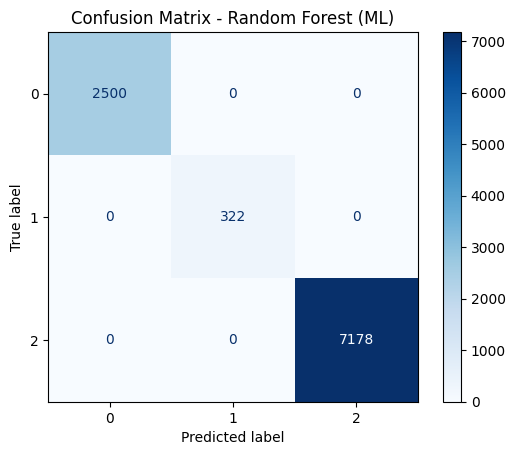

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# targetı sayısal kullan
df['Healthy'] = df['Healthy'].fillna("Unknown")
df['Healthy_LE'] = LabelEncoder().fit_transform(df['Healthy'])

# Feature ve target ayrımı
X = df.select_dtypes(include=['number']).drop(columns=["ID", "Healthy_LE"])
y = df["Healthy_LE"]

# Cross-validation tahminleri
model = RandomForestClassifier()
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y, cv=kfold)

# Confusion matrix oluştur
cm_rf = confusion_matrix(y, y_pred_cv)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
plt.figure(figsize=(6, 4))
disp_rf.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest (ML)")
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df['Healthy'] = df['Healthy'].fillna("Unknown")
df['Healthy_LE'] = LabelEncoder().fit_transform(df['Healthy'])

X = df.select_dtypes(include=['number']).drop(columns=["ID", "Healthy_LE"])
y = df["Healthy_LE"]

# Kullanılacak modeller
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC()
}

# Her model için 5-Fold CV ile performans metriklerini hesapla
model_results = []

for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=5)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro')
    rec = recall_score(y, y_pred, average='macro')
    f1 = f1_score(y, y_pred, average='macro')

    model_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# Sonuçları tablo olarak göster
results_df = pd.DataFrame(model_results)
print("Model Comparison Table (5-Fold Cross-Validation):")
print(results_df)


Model Comparison Table (5-Fold Cross-Validation):
                    Model  Accuracy  Precision    Recall  F1-Score
0     Logistic Regression    1.0000   1.000000  1.000000  1.000000
1           Decision Tree    1.0000   1.000000  1.000000  1.000000
2           Random Forest    1.0000   1.000000  1.000000  1.000000
3     K-Nearest Neighbors    0.8427   0.597691  0.519864  0.536695
4  Support Vector Machine    0.9678   0.643926  0.666667  0.655096


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

df['Healthy'] = df['Healthy'].fillna("Unknown")
df['Healthy_LE'] = LabelEncoder().fit_transform(df['Healthy'])

X = df.select_dtypes(include=['number']).drop(columns=["ID", "Healthy_LE"])
y = df["Healthy_LE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeller ve eğitim süreleri
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC()
}

training_times = []

# Her model için eğitim süresi ölç
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    duration = round(end - start, 4)
    training_times.append({
        "Model": name,
        "Training Time (seconds)": duration
    })

# Sonuçları tablo olarak göster
training_times_df = pd.DataFrame(training_times)
print("Training Time Analysis:")
print(training_times_df)


Training Time Analysis:
                    Model  Training Time (seconds)
0     Logistic Regression                   1.6050
1           Decision Tree                   0.0120
2           Random Forest                   0.4813
3     K-Nearest Neighbors                   0.0025
4  Support Vector Machine                   1.6044


In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

df['Healthy'] = df['Healthy'].fillna("Unknown")
df['Healthy_LE'] = LabelEncoder().fit_transform(df['Healthy'])

X = df.select_dtypes(include=['number']).drop(columns=["ID", "Healthy_LE"])
y = df["Healthy_LE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelleri tanımla ve eğit
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC()
}

for model in models.values():
    model.fit(X_train, y_train)

# Tahmin süresi ölçülecek örnekler
X_sample = X_test.sample(n=100, random_state=42)

# Her model için ortalama tahmin süresini ölç
runtime_efficiency = []

for name, model in models.items():
    start = time.time()
    for i in range(len(X_sample)):
        _ = model.predict(X_sample.iloc[i:i+1])
    end = time.time()
    avg_prediction_time = (end - start) / len(X_sample)
    runtime_efficiency.append({
        "Model": name,
        "Avg Prediction Time (seconds)": round(avg_prediction_time, 6)
    })

# Sonuçları tablo halinde göster
runtime_df = pd.DataFrame(runtime_efficiency)
print("Runtime Efficiency (Average Prediction Time per Sample):")
print(runtime_df)


Runtime Efficiency (Average Prediction Time per Sample):
                    Model  Avg Prediction Time (seconds)
0     Logistic Regression                       0.001024
1           Decision Tree                       0.001178
2           Random Forest                       0.010261
3     K-Nearest Neighbors                       0.003302
4  Support Vector Machine                       0.001924


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

df['Healthy'] = df['Healthy'].fillna("Unknown")
df['Healthy_LE'] = LabelEncoder().fit_transform(df['Healthy'])

X = df.select_dtypes(include=['number']).drop(columns=["ID", "Healthy_LE"])
y = df["Healthy_LE"]

# 1. Chi-Squared
X_chi2 = X.copy()
X_chi2[X_chi2 < 0] = 0  # chi negatif değerle çalışmaz
chi2_selector = SelectKBest(score_func=chi2, k=10)
chi2_selector.fit(X_chi2, y)
chi2_features = X.columns[chi2_selector.get_support()].tolist()

# 2. Mutual Information
mi_selector = SelectKBest(score_func=mutual_info_classif, k=10)
mi_selector.fit(X, y)
mi_features = X.columns[mi_selector.get_support()].tolist()

# 3. Random Forest Feature Importance
rf_model = RandomForestClassifier()
rf_model.fit(X, y)
importances = rf_model.feature_importances_
indices = importances.argsort()[::-1][:10]
rf_features = X.columns[indices].tolist()

# Sonuçları tabloda karşılaştır
feature_selection_df = pd.DataFrame({
    "Chi2": chi2_features,
    "Mutual Info": mi_features,
    "Random Forest Importance": rf_features
})

print("Top 10 Most Important Features (3 Techniques):")
print(feature_selection_df)


Top 10 Most Important Features (3 Techniques):
                      Chi2           Mutual Info Random Forest Importance
0                    Breed                   Age                  Healthy
1                      Age          Weight (lbs)       Spay/Neuter Status
2             Weight (lbs)    Spay/Neuter Status              Medications
3       Spay/Neuter Status  Daily Activity Level                      Age
4                     Diet                  Diet                     Diet
5               Food Brand            Food Brand     Daily Activity Level
6  Other Pets in Household           Medications             Weight (lbs)
7              Medications              Seizures               Food Brand
8                 Seizures        Hours of Sleep                 Seizures
9                  Healthy               Healthy                    Breed
